In [2]:
pip install capytaine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.1 MB/s eta 0:00:00


In [3]:
pip install vtk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 5.6 MB/s eta 0:00:00



--- STL GEOMETRY VERIFICATION ---
Max radial extent : 281.4 mm  (ring Ø280 → expect ~140 mm)
Total Z height    : 86.5 mm  (expect ~86.6 mm = draft)
Total panels      : 3432
⚠ Radius too large (281mm) — check coordinate units (mm vs m?)
✓ Z height matches draft
---------------------------------

--- PRE-TRANSLATE NORMAL CHECK ---
Raw STL signed volume: 1462467.0 mm^3  (0.001462 m^3)
✓ Normals outward — OK
----------------------------------

Detected 90 lid panels at Z≈0 → removing...
Panels after lid removal: 3342

--- POST-CLIP VALIDATION ---
Immersed volume  : 0.001465 m^3  (SW: 0.001465) → ratio 1.0002
Mesh Z range     : -0.0866 to -0.0001 m
  Keel @ Z≈-0.0866 m : ✓
  WL   @ Z≈  0.000  m : ✓
Panel count      : 3342
Expected F3(ω→0) : 619.154 N/m
----------------------------



[12:25:40] WARNING  The rotation dof Roll has been initialized around the origin of the domain (0, 0, 0).

           WARNING  The rotation dof Pitch has been initialized around the origin of the domain (0, 0, 0).

           WARNING  The rotation dof Yaw has been initialized around the origin of the domain (0, 0, 0).

Frequency range : 0.2–15.0 rad/s  (50 points)
Period range    : 0.42–31.42 s
Wave directions : [0.0] rad (0 = head seas)

Solving 350 BEM problems (300 radiation + 50 diffraction)...


[12:25:41] WARNING  Precomputing tabulation, it may take a few seconds.

[12:26:24] WARNING  Mesh resolution for 42 problems:                                                               
                    The resolution of the mesh might be insufficient for omega ranging from 13.490 to 15.000.      
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()


Solve complete.

--- DATASET STRUCTURE ---
Variables : ['added_mass', 'radiation_damping', 'diffraction_force', 'Froude_Krylov_force', 'excitation_force', 'hydrostatic_stiffness']
Coords    : ['g', 'rho', 'body_name', 'water_depth', 'forward_speed', 'wave_direction', 'omega', 'radiating_dof', 'influenced_dof', 'freq', 'period', 'wavenumber', 'wavelength']
wave_direction values: [0.]
-------------------------

--- F3 SANITY CHECK ---
F3 at ω=0.20 rad/s : 618.3493 N/m
Expected ρg∇            : 619.1542 N/m
Ratio                   : 0.999x  (should be ~1.0)
✓ F3 correct
-----------------------

--- A33 SANITY CHECK ---
A33 at ω=0.20 rad/s : 6.0445 kg
Theoretical disk (R=140mm)  : 7.5003 kg
(BEM < theory is expected for real geometry)
------------------------

  HEAVE ADDED MASS & DAMPING
 ω [rad/s]   T [s]    A33 [kg]   B33 [Ns/m]
----------------------------------------------------
     0.200   31.42      6.0445       0.0014
     0.502   12.52      6.0941       0.0226
     0.804    7.81

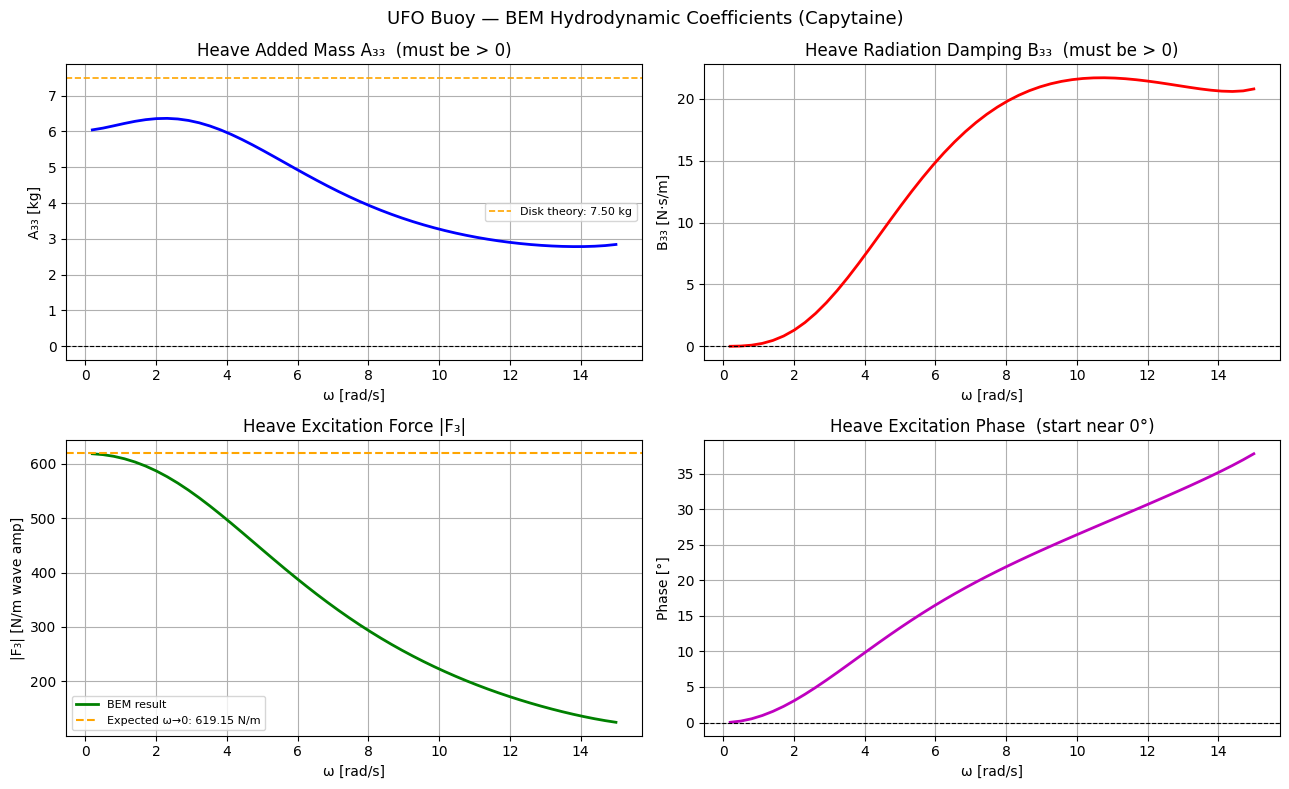


Plot saved: ufo_BEM_results.png


In [4]:
"""
UFO Buoy — Capytaine BEM Analysis
Computes: A33, B33 + Froude-Krylov/excitation forces for all 6 DOF
Exports:  WAMIT-format files for MSS Toolbox (wamit2vessel)

STL REQUIREMENTS:
  ✓ BuoyancyModelPETG STL — full submerged shape INCLUDING the ring/skirt
  ✓ Export from SolidWorks in METRES
  ✓ Coordinate system: keel at Z=0, waterplane at Z=+0.0866m (X_upCoordskeel)
  ✓ The ring IS part of the submerged geometry and correctly affects A33, B33, F3
  ✓ No double-counting: BEM gives freq-dependent A,B; MATLAB gives static C,G

PHYSICAL PROPERTIES (from SolidWorks + MATLAB hydrostatics script):
  Mass       m     = 1.44314 kg
  Draft      T     = 0.0866  m
  Nabla      ∇     = 0.001465 m^3
  KG               = 89.71 mm
  KB               = 56.52 mm
  GM_T             = 172.83 mm
  Ring diameter    = 280 mm  (waterplane)
  Hull diameter    = 200 mm

KNOWN RESULTS (for sanity checking):
  A33(ω→0)  ≈  6.0  kg   (ring dominates: disk formula (8/3)ρR³, R=140mm)
  B33       >  0         (positive, increasing with ω)
  F3(ω→0)  ≈ 619.15 N/m  (= ρgA_wp)
  Phase(ω→0) ≈ 0°
"""

import capytaine as cpt
import numpy as np
import xarray as xr
from capytaine.io.wamit import export_to_wamit
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# PHYSICAL CONSTANTS & KNOWN VALUES
# =============================================================================
rho_sw   = 1025.0          # Seawater density          [kg/m^3]
g_acc    = 9.81            # Gravity                   [m/s^2]
sw_nabla = 1464525.51e-9   # Displaced volume (SW)     [m^3]
DRAFT    = 0.0866          # Equilibrium draft         [m]
D_ring   = 0.280           # Ring/waterplane diameter  [m]
GM_T     = 0.17283         # Transverse GM (MATLAB)    [m]
A_WP = np.pi / 4 * D_ring**2   # Waterplane Area [m^2]
# =============================================================================
# 1. LOAD STL
# =============================================================================
buoy = cpt.FloatingBody.from_file("BUOYANCYMODELPETGFINALMETERS.STL", name="UFO_Buoy")

# --- Geometry verification ---
verts_raw  = buoy.mesh.vertices
max_radius = np.sqrt(verts_raw[:,0]**2 + verts_raw[:,1]**2).max()
z_extent   = verts_raw[:,2].max() - verts_raw[:,2].min()

print(f"\n--- STL GEOMETRY VERIFICATION ---")
print(f"Max radial extent : {max_radius*1e3:.1f} mm  (ring Ø280 → expect ~140 mm)")
print(f"Total Z height    : {z_extent*1e3:.1f} mm  (expect ~86.6 mm = draft)")
print(f"Total panels      : {buoy.mesh.nb_faces}")

# Ring (Ø280mm) should give max_radius ≈ 140mm — this is CORRECT
if max_radius < 0.080:
    print(f"⚠ Radius too small ({max_radius*1e3:.0f}mm) — may be hull only, missing ring")
elif max_radius > 0.160:
    print(f"⚠ Radius too large ({max_radius*1e3:.0f}mm) — check coordinate units (mm vs m?)")
else:
    print(f"✓ Radial extent OK — ring included as expected")

if abs(z_extent - DRAFT) > 0.010:
    print(f"⚠ Z height {z_extent*1e3:.1f}mm ≠ draft {DRAFT*1e3:.1f}mm — check STL origin")
else:
    print(f"✓ Z height matches draft")
print(f"---------------------------------\n")

# =============================================================================
# 2. CHECK NORMALS (before translate — signed volume most reliable here)
# =============================================================================
raw_vol = buoy.volume
print(f"--- PRE-TRANSLATE NORMAL CHECK ---")
print(f"Raw STL signed volume: {raw_vol*1e9:.1f} mm^3  ({raw_vol:.6f} m^3)")
if raw_vol < 0:
    print("⚠ Negative → normals INWARD → flipping...")
    buoy.mesh.flip_normals()
    print(f"  After flip: {buoy.volume:.6f} m^3  ✓")
else:
    print("✓ Normals outward — OK")
print(f"----------------------------------\n")

# =============================================================================
# 3. TRANSLATE: keel → Z = -DRAFT,  waterplane lid → Z = 0
# =============================================================================
buoy.translate([0, 0, -DRAFT])

# =============================================================================
# 4. REMOVE LID PANELS
#    The STL is a closed solid — flat top face sits at Z=0 after translation.
#    These lid panels corrupt BEM (wrong-sign pressure integral).
#    Identify by: centroid Z ≈ 0  AND  normal pointing UP (normal_z > 0.9)
# =============================================================================
verts      = buoy.mesh.vertices
faces      = buoy.mesh.faces
normals    = buoy.mesh.faces_normals
cent_z     = verts[faces, 2].mean(axis=1)

tol    = 0.003   # 3 mm — panels within this of Z=0 considered lid candidates
is_lid = (np.abs(cent_z) < tol) & (normals[:, 2] > 0.9)
n_lid  = is_lid.sum()
print(f"Detected {n_lid} lid panels at Z≈0 → removing...")

if n_lid > 0:
    keep_idx  = np.where(~is_lid)[0]
    new_faces = faces[keep_idx]
    from capytaine.meshes.meshes import Mesh
    clean_mesh = Mesh(vertices=verts, faces=new_faces, name="UFO_clean")
    buoy = cpt.FloatingBody(mesh=clean_mesh, name="UFO_Buoy")
    print(f"Panels after lid removal: {buoy.mesh.nb_faces}")
else:
    print("No lid panels found — STL already open-top ✓")

# =============================================================================
# 5. CLIP TO IMMERSED PART & VALIDATE
# =============================================================================
buoy  = buoy.immersed_part()
vol   = buoy.volume
verts = buoy.mesh.vertices

print(f"\n--- POST-CLIP VALIDATION ---")
print(f"Immersed volume  : {vol:.6f} m^3  (SW: {sw_nabla:.6f}) → ratio {vol/sw_nabla:.4f}")
print(f"Mesh Z range     : {verts[:,2].min():.4f} to {verts[:,2].max():.4f} m")

keel_ok = abs(verts[:,2].min() + DRAFT) < 0.005
wl_ok   = abs(verts[:,2].max())         < 0.005
print(f"  Keel @ Z≈-{DRAFT:.4f} m : {'✓' if keel_ok else '⚠ UNEXPECTED'}")
print(f"  WL   @ Z≈  0.000  m : {'✓' if wl_ok   else '⚠ UNEXPECTED'}")
print(f"Panel count      : {buoy.mesh.nb_faces}")
print(f"Expected F3(ω→0) : {rho_sw*g_acc*A_WP:.3f} N/m")
print(f"----------------------------\n")

# =============================================================================
# 6. DEGREES OF FREEDOM
# =============================================================================
buoy.add_all_rigid_body_dofs()
buoy.rotation_center = np.array([0.0, 0.0, -DRAFT/2])  # suppress DoF warnings

# =============================================================================
# 7. FREQUENCY SWEEP
# =============================================================================
omega_min, omega_max, n_freqs = 0.2, 15.0, 50
frequencies     = np.linspace(omega_min, omega_max, n_freqs)
wave_directions = [0.0]   # head seas — axisymmetric buoy → all dirs equivalent

print(f"Frequency range : {omega_min}–{omega_max} rad/s  ({n_freqs} points)")
print(f"Period range    : {2*np.pi/omega_max:.2f}–{2*np.pi/omega_min:.2f} s")
print(f"Wave directions : {wave_directions} rad (0 = head seas)\n")

# =============================================================================
# 8. BUILD & SOLVE BEM PROBLEMS
# =============================================================================
radiation_problems = [
    cpt.RadiationProblem(body=buoy, radiating_dof=dof, omega=w, rho=rho_sw, g=g_acc)
    for dof in buoy.dofs
    for w in frequencies
]
diffraction_problems = [
    cpt.DiffractionProblem(body=buoy, wave_direction=b, omega=w, rho=rho_sw, g=g_acc)
    for b in wave_directions
    for w in frequencies
]
problems = radiation_problems + diffraction_problems
print(f"Solving {len(problems)} BEM problems "
      f"({len(radiation_problems)} radiation + {len(diffraction_problems)} diffraction)...")

solver  = cpt.BEMSolver()
results = solver.solve_all(problems, keep_details=True)
dataset = cpt.assemble_dataset(results)
print("\nSolve complete.\n")

# =============================================================================
# 9. INJECT HYDROSTATIC STIFFNESS
#    assemble_dataset() without hydrostatics=True avoids mesh-based C computation
#    which fails on open meshes. Use our known values from MATLAB script instead.
# =============================================================================
A_WP = np.pi/4 * D_ring**2
C33  = rho_sw * g_acc * A_WP
C44  = rho_sw * g_acc * sw_nabla * GM_T
C55  = C44

dofs = list(buoy.dofs.keys())
K    = np.zeros((len(dofs), len(dofs)))
for i, d in enumerate(dofs):
    if d == 'Heave': K[i,i] = C33
    if d == 'Roll':  K[i,i] = C44
    if d == 'Pitch': K[i,i] = C55

dataset['hydrostatic_stiffness'] = xr.DataArray(
    K, coords=[('influenced_dof', dofs), ('radiating_dof', dofs)])

# =============================================================================
# 10. EXTRACT RESULTS
# =============================================================================
omegas = dataset.coords['omega'].values
A = dataset['added_mass'].sel(
        radiating_dof='Heave', influenced_dof='Heave').values
B = dataset['radiation_damping'].sel(
        radiating_dof='Heave', influenced_dof='Heave').values

# Print full dataset structure (helps debug coordinate name issues)
print("--- DATASET STRUCTURE ---")
print("Variables :", list(dataset.data_vars))
print("Coords    :", list(dataset.coords))
if 'wave_direction' in dataset.coords:
    print("wave_direction values:", dataset.coords['wave_direction'].values)
print("-------------------------\n")

# Extract excitation force robustly
try:
    F = dataset['excitation_force'].sel(
            influenced_dof='Heave', wave_direction=0.0).values
except KeyError:
    # Fallback: use index selection if coord value doesn't match exactly
    F = dataset['excitation_force'].sel(
            influenced_dof='Heave').isel(wave_direction=0).values

# --- F3 sanity check ---
F3_ref    = rho_sw * g_acc * A_WP   # = 619.15 N/m
F3_at_min = np.abs(F[0])
print(f"--- F3 SANITY CHECK ---")
print(f"F3 at ω={omegas[0]:.2f} rad/s : {F3_at_min:.4f} N/m")
print(f"Expected ρg∇            : {F3_ref:.4f} N/m")
print(f"Ratio                   : {F3_at_min/F3_ref:.3f}x  (should be ~1.0)")
if abs(F3_at_min/F3_ref - 1.0) < 0.20:
    print("✓ F3 correct")
else:
    print("⚠ F3 mismatch — check dataset structure above")
    if 'Froude_Krylov_force' in dataset:
        FK0 = np.abs(dataset['Froude_Krylov_force'].sel(
                influenced_dof='Heave').isel(wave_direction=0).values[0])
        print(f"  FK alone at min ω: {FK0:.4f} N/m")
print(f"-----------------------\n")

# --- A33 sanity check ---
A33_disk   = (8/3) * rho_sw * (D_ring/2)**3   # thin disk theoretical
A33_at_min = A[0]
print(f"--- A33 SANITY CHECK ---")
print(f"A33 at ω={omegas[0]:.2f} rad/s : {A33_at_min:.4f} kg")
print(f"Theoretical disk (R=140mm)  : {A33_disk:.4f} kg")
print(f"(BEM < theory is expected for real geometry)")
print(f"------------------------\n")

# =============================================================================
# 11. PRINT TABLES
# =============================================================================
print("=" * 52)
print("  HEAVE ADDED MASS & DAMPING")
print("=" * 52)
print(f"{'ω [rad/s]':>10}  {'T [s]':>6}  {'A33 [kg]':>10}  {'B33 [Ns/m]':>11}")
print("-" * 52)
for i, w in enumerate(omegas):
    flag = "⚠" if (A[i] < 0 or B[i] < 0) else " "
    print(f"{flag}{w:>9.3f}  {2*np.pi/w:>6.2f}  {A[i]:>10.4f}  {B[i]:>11.4f}")

print(f"\n{'=' * 44}")
print(f"  HEAVE EXCITATION FORCE (β=0°)")
print(f"{'=' * 44}")
print(f"{'ω [rad/s]':>10}  {'|F3| [N/m]':>11}  {'phase [°]':>10}")
print("-" * 36)
for i, w in enumerate(omegas):
    print(f"{w:>10.3f}  {np.abs(F[i]):>11.4f}  {np.angle(F[i], deg=True):>10.2f}")

# =============================================================================
# 12. EXPORT WAMIT FILES
# =============================================================================
print("\nExporting WAMIT files...")
export_to_wamit(dataset, "ufo_output", exports=("1", "3", "3fk", "hst"))
print("✓ ufo_output.1   — added mass & damping")
print("✓ ufo_output.3   — total excitation (FK + diffraction)")
print("✓ ufo_output.3fk — Froude-Krylov only")
print("✓ ufo_output.hst — hydrostatic stiffness")

# Uncomment to download from Colab:
# from google.colab import files
# for f in ["ufo_output.1", "ufo_output.3", "ufo_output.3fk", "ufo_output.hst"]:
#     files.download(f)

# =============================================================================
# 13. PLOTS
# =============================================================================
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle("UFO Buoy — BEM Hydrodynamic Coefficients (Capytaine)", fontsize=13)

    def warn_neg(ax, vals):
        if np.any(np.array(vals) < 0):
            ax.text(0.04, 0.06, '⚠ NEGATIVE VALUES',
                transform=ax.transAxes, color='red', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightyellow'))

    # A33
    axes[0,0].plot(omegas, A, 'b-', lw=2)
    axes[0,0].axhline(0, color='k', lw=0.8, ls='--')
    axes[0,0].axhline(A33_disk, color='orange', lw=1.2, ls='--',
                      label=f'Disk theory: {A33_disk:.2f} kg')
    axes[0,0].set(xlabel='ω [rad/s]', ylabel='A₃₃ [kg]',
                  title='Heave Added Mass A₃₃  (must be > 0)')
    axes[0,0].legend(fontsize=8)
    axes[0,0].grid(True)
    warn_neg(axes[0,0], A)

    # B33
    axes[0,1].plot(omegas, B, 'r-', lw=2)
    axes[0,1].axhline(0, color='k', lw=0.8, ls='--')
    axes[0,1].set(xlabel='ω [rad/s]', ylabel='B₃₃ [N·s/m]',
                  title='Heave Radiation Damping B₃₃  (must be > 0)')
    axes[0,1].grid(True)
    warn_neg(axes[0,1], B)

    # |F3|
    axes[1,0].plot(omegas, np.abs(F), 'g-', lw=2, label='BEM result')
    axes[1,0].axhline(F3_ref, color='orange', lw=1.5, ls='--',
                      label=f'Expected ω→0: {F3_ref:.2f} N/m')
    axes[1,0].set(xlabel='ω [rad/s]', ylabel='|F₃| [N/m wave amp]',
                  title='Heave Excitation Force |F₃|')
    axes[1,0].legend(fontsize=8)
    axes[1,0].grid(True)

    # Phase
    axes[1,1].plot(omegas, np.angle(F, deg=True), 'm-', lw=2)
    axes[1,1].axhline(0, color='k', lw=0.8, ls='--')
    axes[1,1].set(xlabel='ω [rad/s]', ylabel='Phase [°]',
                  title='Heave Excitation Phase  (start near 0°)')
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.savefig("ufo_BEM_results.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\nPlot saved: ufo_BEM_results.png")

except Exception as e:
    print(f"Plot skipped: {e}")
